In [1]:
import itertools

import numpy as np
import scipy as sp
import networkx as nx
import pandas as pd

import igl
import gpytoolbox as gpy

import pyvista as pv
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import cm

from src import shapes, triangletools, vis

# Construct a Complex

In [2]:
import trimesh

mesh = trimesh.load("data/nm-mesh-iso.ply")

vertices = mesh.vertices      # shape (n,3)
faces = mesh.faces            # shape (k,3)

print(vertices.shape, faces.shape)

(11364, 3) (22984, 3)


In [ ]:
mesh = vis.get_pv_mesh(vertices, faces)

pl = pv.Plotter(window_size=(600, 600))
pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=1.0)
pl.show()

Widget(value='<iframe src="http://localhost:34101/index.html?ui=P_0x7e2dca9622a0_0&reconnect=auto" class="pyvi…

Exception raised
ClientConnectionResetError('Cannot write to closing transport')
Traceback (most recent call last):
  File "/home/fzimin/Projects/.venv/lib/python3.12/site-packages/wslink/protocol.py", line 334, in onCompleteMessage
    await self.sendWrappedMessage(
  File "/home/fzimin/Projects/.venv/lib/python3.12/site-packages/wslink/protocol.py", line 439, in sendWrappedMessage
    await ws.send_bytes(chunk)
  File "/home/fzimin/Projects/.venv/lib/python3.12/site-packages/aiohttp/web_ws.py", line 426, in send_bytes
    await self._writer.send_frame(data, WSMsgType.BINARY, compress=compress)
  File "/home/fzimin/Projects/.venv/lib/python3.12/site-packages/aiohttp/_websocket/writer.py", line 90, in send_frame
    self._send_compressed_frame_sync(message, opcode, compress)
  File "/home/fzimin/Projects/.venv/lib/python3.12/site-packages/aiohttp/_websocket/writer.py", line 206, in _send_compressed_frame_sync
    self._write_websocket_frame(
  File "/home/fzimin/Projects/.venv/lib/pyth

# Detect a Boundary

## Define the Boundary Graph and Chains there

In [9]:
def get_boundary_edges(faces):
    """
    """
    face_edges = np.concatenate([faces[:, j] for j in [[0, 1], [0, 2], [1, 2]]])
    face_edges = np.sort(face_edges, axis=1)
    edges = np.unique(face_edges, axis=0)
    edges = edges[(edges[:, None, :] == face_edges).all(axis=-1).sum(axis=-1) != 2]
    return edges


class NonmanifoldBoundaryDetecter:
    def __init__(self, faces, vertices):
        self.faces = np.unique(np.sort(faces, axis=1), axis=0)
        self.vertices = np.array(vertices)

    def get_boundary_edges(self):
        """
        """
        return get_boundary_edges(self.faces)

    def get_conic_vertices(self):
        """
        """
        conic_vertices = []
        for vertex in np.unique(self.faces):
            faces_vertex = faces[(faces == vertex).any(axis=1)]
            connections = faces_vertex[:, None, :, None] == faces_vertex[None, :, None, :]
            connections = connections.any(axis=-1).sum(axis=-1) == 2
            n_components, _ = sp.sparse.csgraph.connected_components(connections, directed=False)
            if n_components > 1:
                conic_vertices.append(vertex)
        conic_vertices = np.array(conic_vertices)
        return conic_vertices

    def get_boundary_graph(self, with_boundary_edges: bool=True, with_conic_vertices: bool=True):
        """
        """
        graph = nx.Graph()
        if with_boundary_edges:
            graph.add_edges_from(self.get_boundary_edges())
        if with_conic_vertices:
            graph.add_nodes_from(self.get_conic_vertices())
        return graph

In [10]:
def get_chains(graph: nx.Graph, similar_start_end_of_cycle=False):
    """
    Returns the list of all chains of the graph.

    A chain is a maximal path whose internal nodes have degree 2
    (endpoints have degree != 2), or (if a connected component is a
    pure cycle where all nodes have degree 2) the whole cycle as one chain.

    Returns
    -------
    list[list[Hashable]]
        Each chain is returned as an ordered list of nodes.
        For cycle-components, the chain is a cyclic order with the first node
        repeated at the end to make the cycle explicit.
    """
    G = graph

    # Degree in a MultiGraph can be >2 because of parallel edges; this function assumes simple graphs,
    # but we still use G.degree(v) which NetworkX defines for any graph.
    deg = dict(G.degree())

    visited_undirected_edges = set()  # store edges as (min(u,v), max(u,v))

    def mark_edge(u, v):
        a, b = (u, v) if u <= v else (v, u)
        visited_undirected_edges.add((a, b))

    def edge_marked(u, v):
        a, b = (u, v) if u <= v else (v, u)
        return (a, b) in visited_undirected_edges

    chains = []

    # 1) Build chains starting from "junctions" / endpoints: nodes with degree != 2
    for start in G.nodes:
        if deg[start] == 2:
            continue

        for nbr in G.neighbors(start):
            if edge_marked(start, nbr):
                continue

            chain = [start]
            prev = start
            cur = nbr
            mark_edge(prev, cur)

            # Walk forward while we're in degree-2 nodes (internal chain nodes)
            while True:
                chain.append(cur)

                if deg[cur] != 2:
                    # We hit a terminal/junction node: chain ends here.
                    break

                # Choose the next neighbor that isn't the previous node
                nbs = list(G.neighbors(cur))
                # In a simple graph with deg==2, there are exactly 2 neighbors.
                nxt = nbs[0] if nbs[0] != prev else nbs[1]

                if edge_marked(cur, nxt):
                    # We've already consumed this edge; stop to avoid duplicates.
                    break

                prev, cur = cur, nxt
                mark_edge(prev, cur)

            chains.append(chain)

    # 2) Remaining edges (if any) belong to components where all nodes have degree 2 => cycles.
    # We treat each such component as one chain (cycle order).
    for comp in nx.connected_components(G):
        comp_nodes = list(comp)
        if not comp_nodes:
            continue
        if any(deg[v] != 2 for v in comp_nodes):
            continue  # not a pure cycle component

        # If all edges in this component are already visited, skip.
        comp_edges = list(G.subgraph(comp_nodes).edges())
        if all(edge_marked(u, v) for (u, v) in comp_edges):
            continue

        # Build an explicit cyclic order by walking until we return to start.
        start = comp_nodes[0]
        nbrs = list(G.neighbors(start))
        if len(nbrs) != 2:
            # Shouldn't happen in a pure cycle, but be defensive.
            continue

        chain = [start]
        prev = start
        cur = nbrs[0]
        mark_edge(prev, cur)

        while True:
            chain.append(cur)
            if cur == start:
                break

            nbs = list(G.neighbors(cur))
            nxt = nbs[0] if nbs[0] != prev else nbs[1]

            # If we're about to close, allow it; otherwise avoid reusing visited edges.
            if edge_marked(cur, nxt) and nxt != start:
                break

            prev, cur = cur, nxt
            mark_edge(prev, cur)

            if cur == start:
                chain.append(start)
                break

        # Ensure it's a cycle representation: end equals start.
        if chain[-1] != start:
            chain.append(start)

        chains.append(chain)

    if not similar_start_end_of_cycle:
        for i, chain in enumerate(chains):
            if chain[0] == chain[-1]:
                chains[i] = chain[:-1]
    chains = [np.array(chain) for chain in chains]

    return chains

## Best Integer Chain Representation

For each chain $i$: $C^i = (v_0^i, ..., v_{k_i}^i)$ let $l_k^i = ||v_{k+1} = v_k||$ be the length of edge. $L^i = \sum_k l_k^i$ be the total length of the chain and $l_{\max}^i = \max_k l_k^i$ be the maximum edge length of the chain.

We have $m$ chains.
And we aim to define natural values $n_1, ..., n_m$ such that for any pair of chains $i, j$
$$
    \frac{n_i}{n_j} \approx \frac{L^i}{L_j}
$$
or let rephrase this in the terms that for some real $s$ for any $i$
$$
    n_i \approx s\cdot L^i
$$

That's also better to define some constrains. In the future on each chain we are going to define a function $t: C^i \to[0, 1]$
$$
    t^i(v_k^i) = \frac{\sum\limits_0^{k - 1} l_k^i}{L_i} 
$$
and after this we will define boundary value as
$$
    f(v_k^i) = \cos(n_i\cdot (2\pi\cdot t^i(v_k^i)))
$$

And we want that between any local maximaand local minima be at least $p=3$ edges. So we will get a linear constraint
$$
    \frac{1}{6\cdot n_i} = \frac{1}{2p\cdot n_i} \ge \frac{l_{\max}^i}{L_i}
$$

Let's also define some balance between equal $n_i$ values and proportinal to the chain lengths with the parameter $\omega \in[0, 1]$. So we will get mixed integer optimization problem:
$$
\sum\limits_{i=1}^m \omega\cdot\left(n_i - sL_i\right)^2 + (1-\omega)\cdot n_i^2 = 
\sum\limits_{i=1}^m n_i^2 + 2\omega \cdot sL_i + \omega\cdot s^2 \to \min 
$$

with constrains
$$
s \in \mathbb{R}, n_i \in\mathbb{Z}
$$
$$
    1 \le n_i \le \frac{L_i}{2p\cdot l_{\max}^i} = \frac{L_i}{6\cdot l_{\max}^i}
$$

In [11]:
import cvxpy as cp

In [114]:
def get_integer_chain_representation(chains, vertices, p=3, omega=1.0):
    """
    Get the best integer chain representation defining and solving a mixed-integer optimization problem.

    Parameters:
    -----------
    chains: list[np.array[int]]
        The chains of the boundary defined as indices of vertices
    
    vertices: np.array
        The vertices of the complex
    
    p: int
        Minimal number of edges between local minimas and local maximas

    omega: float
        The result is closer to chain lengths against uniform

    Retruns:
    --------
    n : np.array length len(chains)
        The integre representation of chain lengths
    """
    if isinstance(vertices, dict):
        chain_edge_lengths = [np.linalg.norm([vertices[v0] - vertices[v1] for v0, v1 in itertools.pairwise(chain)], axis=-1) for chain in chains]
    else:
        chain_edge_lengths = [np.linalg.norm(vertices[chain[1:]] - vertices[chain[:-1]], axis=-1) for chain in chains]
    chain_lengths_total = np.array([np.sum(edge_lengths) for edge_lengths in chain_edge_lengths])
    chain_lengths_max = np.array([np.max(edge_lengths) for edge_lengths in chain_edge_lengths])

    right_constrains = chain_lengths_total/(2*p*chain_lengths_max)

    # variables
    n = cp.Variable(len(chains), integer=True)
    s = cp.Variable()
    constraints = [n >= 1, n <= right_constrains]

    # objective
    objective = cp.Minimize(omega*cp.sum_squares(n - s*chain_lengths_total) + (1 - omega)*cp.sum_squares(n))

    # problem
    prob = cp.Problem(objective, constraints)

    # choose a mixed-integer solver you have installed
    prob.solve(solver=cp.GUROBI)   # or SCIP / CPLEX / MOSEK if available

    #print("status:", prob.status)
    #print("objective:", prob.value)
    #print("n:", np.round(n.value).astype(int))
    #print("s:", s.value)

    n = np.round(n.value).astype(int)
    return n

## Finally Define the Values on the Boundary

In [115]:
def get_boundary_values(graph, vertices_pos, default_value=1, p=3, omega=1.0):
    """
    """
    if isinstance(vertices_pos, dict):
        d = len(next(graph.values().__iter__()))
        n = np.max(graph.nodes()).astype(int) + 1
        vertices = np.nan*np.zeros([n, d])
        for node, pos in vertices_pos.items():
            vertices[node] = pos
    else:
        vertices = np.array(vertices_pos)

    chains = get_chains(graph, similar_start_end_of_cycle=True)
    chain_lengths = np.array([np.linalg.norm(vertices[chain[1:]] - vertices[chain[:-1]], axis=-1).sum() for chain in chains])
    #chain_lengths_int = best_integer_shape(chain_lengths, n_max=n_max, metric=metric, alphas=alphas, refine_steps=refine_steps)
    chain_lengths_int = get_integer_chain_representation(chains, vertices, p=p, omega=omega)

    node_list = np.array(list(graph.nodes))
    node_to_vertex = -1*np.ones(vertices.shape[0], dtype=int)
    node_to_vertex[node_list] = np.arange(len(node_list))

    vec_val = np.zeros(graph.number_of_nodes()) + default_value
    for i, (chain, length, length_int) in enumerate(zip(chains, chain_lengths, chain_lengths_int)):
        vec_t = np.append(0, np.linalg.norm(vertices[chain][1:] - vertices[chain][:-1], axis=1).cumsum()) / length
        vec_val[node_to_vertex[chain]] = np.cos(2*length_int*np.pi*vec_t)
        
    return vec_val

In [116]:
nmb = NonmanifoldBoundaryDetecter(faces, vertices)
boundary_graph = nmb.get_boundary_graph()
boundary_graph_pos = {node: nmb.vertices[node] for node in boundary_graph.nodes}

boundary_values = get_boundary_values(boundary_graph, vertices)
boundary_indices = np.array(list(boundary_graph.nodes()))

norm_val = mcolors.TwoSlopeNorm(vmin=boundary_values.min(), vcenter=0, vmax=abs(boundary_values).max())
node_colors_val = [c for c in plt.get_cmap('coolwarm')(norm_val(boundary_values))]


In [117]:
node_colors_val = [c for c in plt.get_cmap('coolwarm')(norm_val(boundary_values))]


In [118]:
pl = pv.Plotter(window_size=(1000, 600))

pl.add_mesh(mesh, color='white', smooth_shading=False, show_edges=True, opacity=0.3)
vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_val
                         , edge_color='black', edge_width=2, node_size=10, add_labels=False)

pl.link_views()
pl.show()

Widget(value='<iframe src="http://localhost:34101/index.html?ui=P_0x7e2d07e1dbb0_12&reconnect=auto" class="pyv…

# Remashing

For the given manifold $M$ with a boundary $\partial M$ and the function on a boundary $f: \partial M\to \mathbb{R}$  with defined critical points $\text{Crit}(f) = \text{Crit}^\text{min}(f) \cup \text{Crit}^\text{max}(f)$ we aim to extenf $f$ into $\hat{f}: M\to\mathbb{R}$ ($\hat{f}(x) = f(x)\; \forall x\in\partial M$) preserving $f$ integral lines and critical and regular points on a boundary.

Let's do this in a way, that $\text{Crit}^\text{max}(f) \to \text{Crit}^\text{max}(\hat{f})$ and $\text{Crit}^\text{min}(f) \to \text{Crit}^\text{saddle}(\hat{f})$.

Then the mesh on a boundory $\partial M$ require 2 statements:
1. Each face of the mesh should have maximumu one edge from a boundary (or two edges connected by critical point)
2. Each vertex $s\in \text{Crit}^\text{min}(f)$ should have at least one neighbor $v\in M/\partial M$ such that $s$ is the onlye $v$'s neighbor feom the boundary ($\text{Neighbors}(v)\cap\partial M = \{s\}$).


__Problem:__ functions `flip_ears` and `split_edges_arroud_saddles` does not take a boundary as an argument and define this inside. But fboundaryor nonmanifold surface each manifold component have predefined .
So I should rewrite these functions with an additional array argument `boundary_indices`. I can define this from a triangulation if this arguent is `None.`

## Flip Ears

We can remesh given triangulation, removing ears, and get the mesh, satisfying the 1st statement.

In [119]:
def flip_ears_defining_boundary(faces):
    """
    """
    ears, ear_opp = igl.ears(faces)

    mask = ear_opp.reshape(-1, 1) != np.arange(3)
    edges_to_flip = faces[ears][mask].reshape(-1, 2)

    faces_contains_fliping_edges = (faces[:, np.array(list(itertools.combinations(range(3), 2)))][..., None, :] == edges_to_flip).all(axis=-1).any(axis=-2)
    assert (faces_contains_fliping_edges.sum(axis=0) == 2).all()
    _face_idx, _edge_idx = np.where(faces_contains_fliping_edges)
    faces_fliping_edges = _face_idx.reshape(-1, 2)
    faces_contains_fliping_edges = faces_contains_fliping_edges.any(axis=1)

    opposite_vertives = faces[faces_fliping_edges].reshape(-1, 6)
    mask = (opposite_vertives[:, None, :] != edges_to_flip[:, :, None]).all(axis=-2)
    opposite_vertives = opposite_vertives[mask].reshape(-1, 2)
    
    new_faces = np.vstack([np.hstack([opposite_vertives, edges_to_flip[:, i].reshape(-1, 1)]) for i in range(2)])
    new_faces = np.vstack([faces[~faces_contains_fliping_edges], new_faces])
    new_faces = np.sort(new_faces, axis=1)
    
    return new_faces

In [120]:
test_faces = np.array([[0, 1, 3], [1, 3, 4], [1, 2, 4], [2, 4, 5], 
                       [3, 4, 6], [4, 6, 7], [4, 5, 7], [5, 8, 7]])


print(f'test_faces.shape = {test_faces.shape}')
test_faces

test_faces.shape = (8, 3)


array([[0, 1, 3],
       [1, 3, 4],
       [1, 2, 4],
       [2, 4, 5],
       [3, 4, 6],
       [4, 6, 7],
       [4, 5, 7],
       [5, 8, 7]])

In [121]:
fliped_faces = flip_ears_defining_boundary(test_faces)
print(f'fliped_faces.shape = {fliped_faces.shape}')

fliped_faces

fliped_faces.shape = (8, 3)


array([[1, 2, 4],
       [2, 4, 5],
       [3, 4, 6],
       [4, 6, 7],
       [0, 1, 4],
       [4, 5, 8],
       [0, 3, 4],
       [4, 7, 8]])

In [122]:
def flip_ears(faces, boundary_edges=None):
    """
    """
    if boundary_edges is None:
        return flip_ears_defining_boundary(faces)
    pass


In [123]:
test_faces = np.array([(0, 1, 2), (1, 2, 3), 
                       (0, 2, 5), (2, 5, 6), 
                       (2, 3, 6), (3, 4, 6), 
                       (4, 6, 7), (5, 6, 7)])
test_faces

array([[0, 1, 2],
       [1, 2, 3],
       [0, 2, 5],
       [2, 5, 6],
       [2, 3, 6],
       [3, 4, 6],
       [4, 6, 7],
       [5, 6, 7]])

In [124]:
test_boundary_edges = np.array([(1, 3), (2, 3), (2, 6), (5, 6)])
test_boundary_edges

array([[1, 3],
       [2, 3],
       [2, 6],
       [5, 6]])

In [125]:
ear_faces = (np.sort(test_faces, axis=1)[:, [list(i) for i in itertools.combinations(range(3), 2)]][..., None, :] == np.sort(test_boundary_edges, axis=1)).all(axis=-1).sum(axis=(1, 2)) == 2
test_faces[ear_faces]

array([[1, 2, 3],
       [2, 5, 6],
       [2, 3, 6]])

## Surrounding Saddles Area 

In [126]:
from src.shapes import split_edge

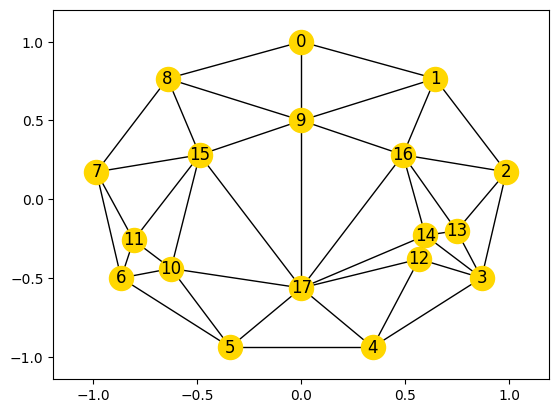

In [127]:
boundary = np.linspace(0, 2*np.pi, 10)[:-1]
boundary = np.transpose([np.sin(boundary), np.cos(boundary)])

saddle0_surrounding = [[0, 0.5]]
saddle1_surrounding = boundary[6] + 0.3*np.array([[0.8, 0.2], [0.2, 0.8]])
saddle2_surrounding = boundary[3] + 0.3*np.array([[-1.0, 0.4], [-0.4, 1.0], [-0.9, 0.9]])

regular_points = [0.6*boundary[edge].mean(axis=0) for edge in [[7, 8], [1, 2], [4, 5]]]


test_vertices = np.vstack([boundary, 
                           saddle0_surrounding, 
                           saddle1_surrounding, 
                           saddle2_surrounding, 
                           regular_points
                           ])

test_faces = sp.spatial.Delaunay(test_vertices).simplices
test_faces = np.sort(test_faces, axis=1)
test_faces = test_faces[(test_faces[:, None, :] != np.array([[3, 12, 13], [12, 13, 14]])).all(axis=1).any(axis=1)]
test_faces = np.vstack([test_faces, [[3, 12, 14], [3, 13, 14]]])


test_graph = nx.Graph()
test_graph.add_nodes_from(range(test_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    test_graph.add_edges_from(test_faces[:, list(i)])

nx.draw_networkx(test_graph, pos=test_vertices, hide_ticks=False, node_color='gold')
plt.grid(False)
plt.show()


In [128]:
def split_edges_arroud_saddles(vertices, faces, saddles, edge_choice_strategy='longest'):
    """
    """
    bnd_edges, bnd_face_indices, bnd_local_edge_indices = igl.boundary_facets(test_faces)
    #assert np.isin(saddles, np.unique(bnd_edges)).all()
    bnd_vertices = np.unique(bnd_edges)

    bnd_vertices_nonsaddles = bnd_vertices[~np.isin(bnd_vertices, saddles)]

    adj_full = igl.adjacency_matrix(faces)
    
    saddle_neighbors = np.argwhere(adj_full[saddles])
    saddle_neighbor_is_far_from_boundary = (adj_full[:, bnd_vertices_nonsaddles][saddle_neighbors[:, 1]].toarray() == 0).all(axis=1)

    good_saddles = saddles[saddle_neighbors[:, 0][saddle_neighbor_is_far_from_boundary]]
    

    if set(good_saddles) == set(saddles):
        return vertices, faces
    
    if isinstance(edge_choice_strategy, str):
        if edge_choice_strategy == 'longest':
            f_edge_choice_strategy = lambda edges: np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).argmax()
        if edge_choice_strategy == 'shortest':
            f_edge_choice_strategy = lambda edges: np.linalg.norm(vertices[edges[:, 0]] - vertices[edges[:, 1]], axis=1).argmin()
    else:
        f_edge_choice_strategy = edge_choice_strategy

    saddles_to_split_arround = saddles[~np.isin(saddles, good_saddles)]

    new_vertices, new_faces = vertices.copy(), faces.copy()
    for saddle in saddles_to_split_arround:
        saddle_faces = faces[(faces == saddle).any(axis=1)]
        mask = saddle_faces != saddle
        saddle_edges = saddle_faces[mask].reshape(-1, 2)

        e0, e1 = saddle_edges[f_edge_choice_strategy(saddle_edges)]
        new_vertices, new_faces = split_edge(new_vertices, new_faces, e0, e1)
    return split_edges_arroud_saddles(new_vertices, new_faces, saddles, edge_choice_strategy=edge_choice_strategy)

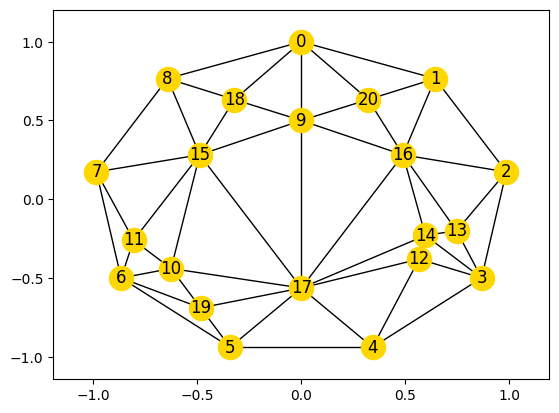

In [129]:
new_vertices, new_faces = split_edges_arroud_saddles(test_vertices, test_faces, np.array([0, 3, 6]))#.toarray()


new_graph = nx.Graph()
new_graph.add_nodes_from(range(new_vertices.shape[0]))
for i in itertools.combinations(range(3), 2):
    new_graph.add_edges_from(new_faces[:, list(i)])

nx.draw_networkx(new_graph, pos=new_vertices, hide_ticks=False, node_color='gold')
plt.grid(False)
plt.show()


# Boundary Inequality System Solution

## Detect critical points on the boundary

In [130]:
def detect_mins(faces, bnd_indices, bnd_vals):
    """
    """
    adj = igl.adjacency_matrix(faces)
    adj = adj[bnd_indices][:, bnd_indices].toarray().astype(bool)

    cond = (~adj | (bnd_vals > bnd_vals.reshape(-1, 1))).all(axis=1)
    bnd_mins = bnd_indices[cond]
    return bnd_mins


def detect_maxs(faces, bnd_indices, bnd_vals):
    """
    """
    return detect_mins(faces, bnd_indices, -bnd_vals)



In [131]:
def detect_cons(faces, bnd_indices):
    """
    """
    adj = igl.adjacency_matrix(faces)
    adj = adj[bnd_indices][:, bnd_indices].toarray()
    #bnd_cons = bnd_indices[adj.sum(axis=1) == 0]
    bnd_cons = bnd_indices[~adj.any(axis=1)]
    return bnd_cons

In [132]:
def detect_boundary_parameters(vertices, faces, default_value=1, p=3, omega=1.0):
    """
    """
    nmb = NonmanifoldBoundaryDetecter(faces, vertices)
    boundary_graph = nmb.get_boundary_graph()
    boundary_indices = np.array(list(boundary_graph.nodes()))
    boundary_values = get_boundary_values(boundary_graph, vertices, default_value=default_value, p=p, omega=omega)
    boundary_mins = detect_mins(faces, boundary_indices, boundary_values)
    boundary_maxs = detect_maxs(faces, boundary_indices, boundary_values)
    #boundary_cons = np.array([node for node in boundary_graph.nodes() if boundary_graph.degree[node] == 0])
    boundary_cons = detect_cons(faces, boundary_indices)


    return boundary_indices, boundary_values, boundary_mins, boundary_maxs, boundary_cons

## Preparing an Example

In [133]:
def plot_as_graph(vertices, faces, values, cmap='spring', none_color='grey', normalizer=None, ax=None):
    """
    """
    graph_u = nx.Graph()
    graph_u.add_nodes_from(range(len(vertices)))
    graph_u.add_edges_from(np.vstack([faces[:, list(i)] for i in itertools.combinations(range(3), 2)]))

    if ax is None:
        ax = plt.gca()

    if normalizer is None:
        min_val = values[~np.isnan(values)].min()
        max_val = values[~np.isnan(values)].max()
        normalizer = lambda val: (val - min_val)/(max_val - min_val)
    cmap = plt.get_cmap(cmap)
    node_colors = [none_color if np.isnan(values[node]) else mcolors.to_hex(cmap(normalizer(values[node]))) for node in graph_u.nodes()]

    nx.draw_networkx(graph_u, pos=vertices, node_color=node_colors, ax=ax)

    graph_d = nx.DiGraph()
    graph_d.add_nodes_from(range(len(vertices)))
    for e0, e1 in graph_u.edges():
        if values[e1] > values[e0]:
            graph_d.add_edge(e1, e0)
        if values[e1] < values[e0]:
            graph_d.add_edge(e0, e1)

    nx.draw_networkx(graph_d, pos=vertices, node_color=node_colors, ax=ax)

In [141]:
np.random.seed(0)

test_r = np.linspace(0, 1, 64)**0.8
n = len(test_r)

test_phi = 2*np.pi*np.random.random(n)
test_vertices = test_r.reshape(-1, 1)*np.transpose([np.cos(test_phi), np.sin(test_phi)])
test_faces = sp.spatial.Delaunay(test_vertices).simplices
test_faces = flip_ears(test_faces)

(test_boundary_indices, 
 test_boundary_values, 
 test_boundary_mins, 
 test_boundary_maxs, 
 test_boundary_cons) = detect_boundary_parameters(test_vertices, test_faces, omega=1.0)


test_vertices, test_faces = split_edges_arroud_saddles(test_vertices, test_faces, test_boundary_mins)
test_vertices, test_faces = split_edges_arroud_saddles(test_vertices, test_faces, test_boundary_maxs)

test_values = np.nan*np.ones(len(test_vertices))
test_values[test_boundary_indices] = test_boundary_values

print(f'test_vertices.shape = {test_vertices.shape}')
print(f'test_faces.shape = {test_faces.shape}')
print(f'test_values.shape = {test_values.shape}')

print()
print(f'test_boundary_mins: {test_boundary_mins}')
print(f'test_boundary_maxs: {test_boundary_maxs}')

test_vertices.shape = (64, 2)
test_faces.shape = (114, 3)
test_values.shape = (64,)

test_boundary_mins: [49]
test_boundary_maxs: [38]


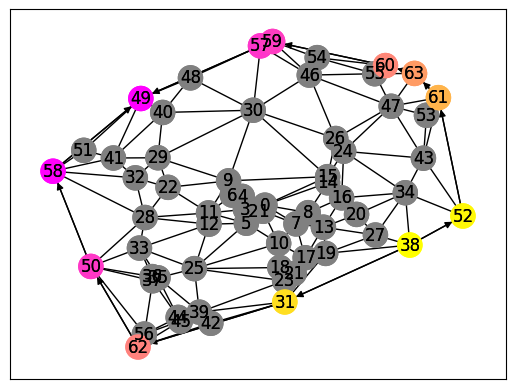

In [142]:
plot_as_graph(test_vertices, test_faces, test_values)

## Description of Steps

1. Define values arround local minimas of the boundary, making the saddle from this
2. Go along boundaries from their local minimas to their local maximas: defining values arround, which preserves integral lines on the boundary
3. Define values arround the boundary local maximas and isolated conic vertices, preserving them beiing local maxima. 

## Technical Methods

In [143]:
def get_surrounding_chains(faces, center, defined_values=[]):
    """
    """
    surrounding_faces = faces[(faces == center).any(axis=1)]
    surrounding_edges = surrounding_faces[surrounding_faces != center].reshape(-1, 2)
    surrounding_nodes = np.unique(surrounding_edges)
    surrounding_graph = nx.Graph()
    surrounding_graph.add_nodes_from(surrounding_nodes)
    surrounding_graph.add_edges_from(surrounding_edges)
    surrounding_defined_values = np.intersect1d(defined_values, surrounding_nodes)

    artificial_nodes = np.max(list(surrounding_graph.nodes())) + np.arange(1, 3)
    for artificial_node in artificial_nodes:
        surrounding_graph.add_edges_from([(artificial_node, outer) for outer in surrounding_defined_values])
    
    surrounding_chains = [chain for chain in get_chains(surrounding_graph) if (len(chain) > 2) and not np.isin(chain, artificial_nodes).any()]
    return surrounding_chains
    

In [144]:
surr_faces = np.array([(0, i+1, (i+1)%12 + 1) for i in range(12)])
surr_center = 0
surr_defined_values = [0, 1, 2, 5, 9]


get_surrounding_chains(faces=surr_faces, center=surr_center, defined_values=surr_defined_values)

[array([ 1, 12, 11, 10,  9]), array([2, 3, 4, 5]), array([5, 6, 7, 8, 9])]

## Define the Values Arround Local Mininimas, Creating the Saddles

In [145]:
def have_boundary_neighbor(faces, boundary_indices, vertices_indices):
    """
    """
    adj = igl.adjacency_matrix(faces)[boundary_indices, :][:, vertices_indices]
    res = adj.toarray().sum(axis=0) > 0
    return res

In [146]:
def define_values_arround_local_min(faces, values, vertices, boundary_indices, min_index, alpha=0.5):
    """
    """
    new_values = values.copy()

    for chain in get_surrounding_chains(faces, center=min_index, defined_values=boundary_indices):
        chain_have_boundary_neighbor = have_boundary_neighbor(faces, boundary_indices[boundary_indices != min_index], chain)
        #if chain_have_boundary_neighbor.all():
        #    raise ValueError(f"Impossible to define saddle values in the minima {min_index}: all it's neighbors have another boundary neighbor")
        
        ls = np.linalg.norm(vertices[chain[1:]] - vertices[chain[:-1]], axis=-1)
        ts = np.append(0, np.cumsum(ls)/ls.sum())

        val_a = values[min_index]
        val_b0, val_b1 = values[chain[[0, -1]]]
        delta = alpha*min(val_b0 - val_a, val_b1 - val_a)
        chain_val_a = val_a - delta*0.5*(1 - np.cos(2*np.pi*ts))
        #chain_val = val_b0 + ts*(val_b1 - val_b0) + chain_val_add
        #chain_val[~chain_have_boundary_neighbor] = val_a - chain_val_add[~chain_have_boundary_neighbor]
        chain_val_b0 = val_b0 + delta*np.sin(0.5*np.pi*ts)
        chain_val_b1 = val_b1 + delta*np.sin(0.5*np.pi*(1 - ts))
        
        chain_components = np.cumsum(np.r_[0, chain_have_boundary_neighbor[1:] != chain_have_boundary_neighbor[:-1]])
        #chain_val = np.zeros_like(chain_val_a)
        #chain_val[chain_components == 0] = chain_val_b0[chain_components == 0] 
        #chain_val[chain_components == 1] = chain_val_a[chain_components == 1] 
        #chain_val[chain_components == 2] = chain_val_b1[chain_components == 2] 
        #chain_val_add =  delta*0.5*(1 - np.cos(2*np.pi*ts))
        #chain_val = val_b0 + ts*(val_b1 - val_b0) + chain_val_add

        chain_val = chain_val_a
        #plt.plot(ts, chain_val)
        #plt.plot([0, 1], [val_a, val_a])
        #plt.show()
        
        new_values[chain] = chain_val
    return new_values

## Walk Along Boundary Integral Lines from Lower to Higher

In [147]:
def iterate_all_maximal_paths_in_dag(G: nx.DiGraph):
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("G must be a DAG")

    sources = [n for n in G.nodes if G.in_degree(n) == 0]

    def dfs(path):
        u = path[-1]
        succ = list(G.successors(u))
        if not succ:                 # sink => path is maximal
            yield path
            return
        for v in succ:
            yield from dfs(path + [v])

    for s in sources:
        yield from dfs([s])

In [148]:
def iterate_integral_lines_over_the_boundary(faces, bnd_indices, bnd_values, direction_from_min_to_max=True):
    """
    """
    bnd_faces = faces[np.isin(faces, bnd_indices).sum(axis=1) == 2]
    bnd_edges = bnd_faces[np.isin(bnd_faces, bnd_indices)].reshape(-1, 2)
    bnd_thirds = bnd_faces[~np.isin(bnd_faces, bnd_indices)]
    assert (np.sort(bnd_faces, axis=1) == np.sort(np.hstack([bnd_edges, bnd_thirds.reshape(-1, 1)]), axis=1)).all()

    assert np.isin(bnd_edges, bnd_indices).all()


    bnd_val_dict = {key: value for key, value in zip(bnd_indices, bnd_values)}
    bnd_edge_vals = np.vectorize(bnd_val_dict.get)(bnd_edges)
    if direction_from_min_to_max:
        bnd_edges[bnd_edge_vals[:, 1] < bnd_edge_vals[:, 0]] = bnd_edges[bnd_edge_vals[:, 1] < bnd_edge_vals[:, 0]][:, [1, 0]]
    else:
        bnd_edges[bnd_edge_vals[:, 1] > bnd_edge_vals[:, 0]] = bnd_edges[bnd_edge_vals[:, 1] > bnd_edge_vals[:, 0]][:, [1, 0]]

    bnd_graph = nx.DiGraph()
    for (e0, e1), third_vertex in zip(bnd_edges, bnd_thirds):
        bnd_graph.add_edge(e0, e1, third=third_vertex)
    
    for path in iterate_all_maximal_paths_in_dag(bnd_graph):
        yield np.array(path)

In [149]:
integral_paths = list(iterate_integral_lines_over_the_boundary(test_faces, test_boundary_indices, test_values[test_boundary_indices]))
integral_paths

[array([49, 58, 50, 62, 31, 38], dtype=int32),
 array([49, 57, 59, 60, 63, 61, 52, 38], dtype=int32)]

In [150]:
def iterate_edge_common_neighbors_over_path(faces, path):
    """
    """
    adj = igl.adjacency_matrix(faces).toarray().astype(bool)

    for e0, e1 in itertools.pairwise(path):
        common_neighbors = np.argwhere(adj[e0] & adj[e1]).ravel()
        yield (e0, e1), common_neighbors

In [151]:
list(iterate_edge_common_neighbors_over_path(test_faces, integral_paths[0]))

[((np.int32(49), np.int32(58)), array([41, 51])),
 ((np.int32(58), np.int32(50)), array([28])),
 ((np.int32(50), np.int32(62)), array([56])),
 ((np.int32(62), np.int32(31)), array([42])),
 ((np.int32(31), np.int32(38)), array([19]))]

In [152]:
def update_values_over_integral_path(faces, values, vertices, path):
    """
    """
    new_values = values.copy()
    for (e0, e1), common_neighbors in iterate_edge_common_neighbors_over_path(faces, path):
        vertices_to_update = common_neighbors[np.isnan(new_values[common_neighbors])]
        l0 = np.linalg.norm(vertices[vertices_to_update] - vertices[e0], axis=1)
        l1 = np.linalg.norm(vertices[vertices_to_update] - vertices[e1], axis=1)
        
        val0, val1 = values[[e0, e1]]
        ts = l0/(l0 + l1)
        vals_up = val0 + ts*(val1 - val0)
        new_values[vertices_to_update] = vals_up
    return new_values

        
        

## Define the Values Arround Boundary Regular Points, Local Maximas or Isolated Conic Vertices

In [153]:
def update_values_regularly(faces, values, vertices, vertex_index, derivative=-0.2):
    """
    """
    new_values = values.copy()
    defined_values = np.argwhere(~np.isnan(new_values)).ravel()

    val_center = new_values[vertex_index]

    for chain in get_surrounding_chains(faces, vertex_index):
        val0 = new_values[chain[0]]
        val1 = new_values[chain[-1]]
        if np.isnan(val0):
            val0 = val_center + derivative*np.linalg.norm(vertices[vertex_index] - vertices[chain[0]])
        if np.isnan(val1):
            val1 = val_center + derivative*np.linalg.norm(vertices[vertex_index] - vertices[chain[-1]])
        
        ls = np.linalg.norm(vertices[chain[1:]] - vertices[chain[:-1]], axis=1)
        ts = np.append(0, np.cumsum(ls))/np.sum(ls)
        vals_up = val0 + ts*(val1 - val0)
        cond_up = np.isnan(values[chain])
        new_values[chain[cond_up]] = vals_up[cond_up]
    return new_values

## Solve The Harmonic Equation predefining the Second Boundary Constrains

In [154]:
def get_second_boundary_values(vertices, faces, boundary_indices, boundary_values, 
                               alpha=0.5, derivative=-0.2, return_values=False):
    """
    """
    values = np.nan*np.zeros(len(vertices))
    values[boundary_indices] = boundary_values
    
    boundary_mins = detect_mins(faces, boundary_indices, boundary_values)
    boundary_maxs = detect_maxs(faces, boundary_indices, boundary_values)
    #boundary_cons = pass

    for min_index in boundary_mins:
        values = define_values_arround_local_min(faces, values, vertices, boundary_indices, min_index=min_index, alpha=alpha)

    #for max_index in boundary_maxs:
    #    values = update_values_regularly(faces, values, vertices, max_index, derivative=derivative)

    integral_paths = list(iterate_integral_lines_over_the_boundary(faces, boundary_indices, boundary_values))
    for integral_path in integral_paths:
        values = update_values_over_integral_path(faces, values, vertices, integral_path)

    #oredered_vertices = np.concatenate(integral_paths)
    #oredered_vertices = oredered_vertices[~np.isin(oredered_vertices, boundary_maxs)]
    #oredered_vertices = np.concatenate([boundary_maxs, oredered_vertices])
    #oredered_vertices = np.concatenate([oredered_vertices, boundary_maxs])
    #print(oredered_vertices)
    #for vertex_id in oredered_vertices:
    #    values = update_values_regularly(faces, values, vertices, vertex_id, derivative=derivative)
    
    #for con_index in boundary_cons:
    #    values = update_values_regularly(faces, values, vertices, con_index, derivative=derivative)

    
    if return_values:
        return values
    
    second_boundary_indices = np.argwhere(~np.isnan(values)).ravel()
    second_boundary_values = values[second_boundary_indices]


    return second_boundary_indices, second_boundary_values

test_boundary_mins: [49]
test_boundary_maxs: [38]


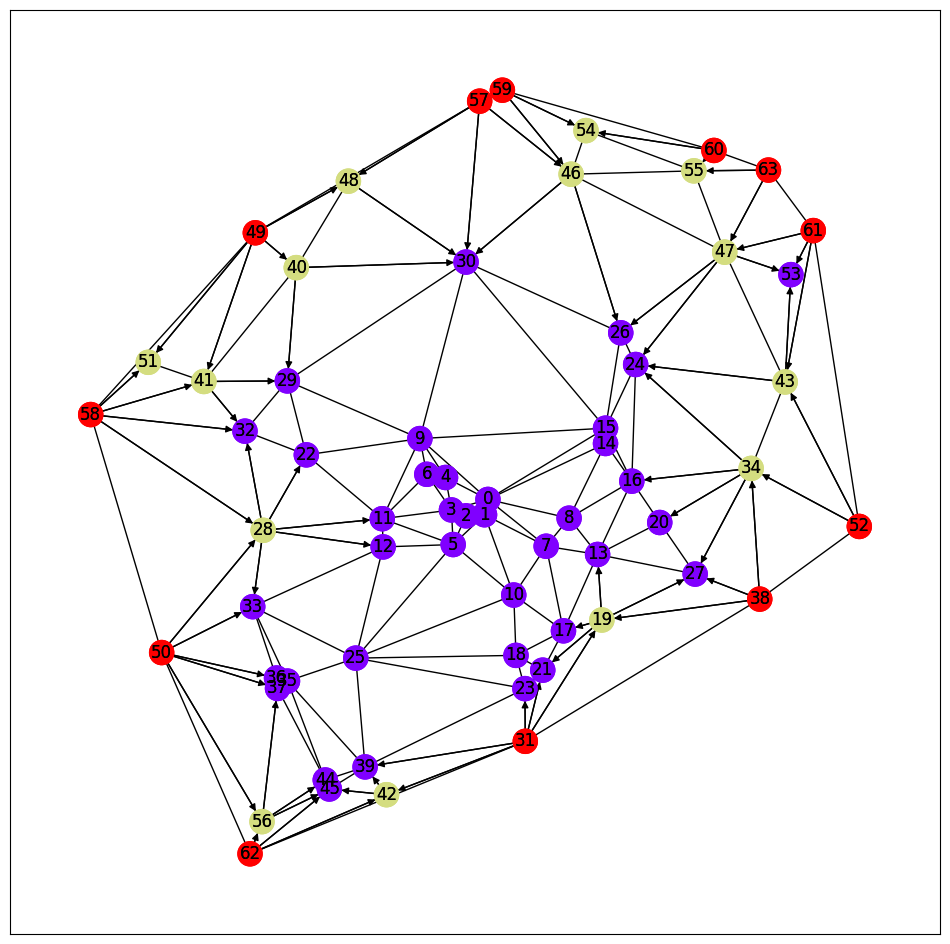

In [155]:
test_second_boundary_indices, test_second_boundary_values = get_second_boundary_values(test_vertices, test_faces, test_boundary_indices, test_boundary_values)


test_boundary_status = np.zeros(len(test_vertices))
test_boundary_status[test_boundary_indices] += 1
test_boundary_status[test_second_boundary_indices] += 2

print(f'test_boundary_mins: {test_boundary_mins}')
print(f'test_boundary_maxs: {test_boundary_maxs}')
plt.figure(figsize=(12, 12))
plot_as_graph(test_vertices, test_faces, test_boundary_status, cmap='rainbow')


In [156]:
from src.triangletools import compact_mesh

def solve_second_boundary_hermonics(vertices, faces, boundary_indices, boundary_values, 
                                    alpha=0.5, derivative=-0.2, return_values=False, k=2):
    """
    """
    second_boundary_indices, second_boundary_values = get_second_boundary_values(vertices, faces, boundary_indices, boundary_values, 
                                                                                 alpha=alpha, derivative=derivative)

    faces_small = faces[~np.isin(faces, boundary_indices).any(axis=1)]
    vertices_small, faces_small, big2small, small2big = compact_mesh(vertices, faces_small)

    second_boundary_indices_small = big2small[second_boundary_indices]
    bc = second_boundary_values[second_boundary_indices_small != -1].reshape(-1, 1)
    b = second_boundary_indices_small[second_boundary_indices_small != -1]

    u_small = igl.harmonic(vertices_small, faces_small, b, bc, k).ravel()

    u = np.nan*np.ones(len(vertices))
    u[small2big[np.arange(len(u_small))]] = u_small
    u[second_boundary_indices] = second_boundary_values
    u[boundary_indices] = boundary_values

    return u

In [157]:
test_harmonic_values = solve_second_boundary_hermonics(test_vertices, test_faces, test_boundary_indices, test_boundary_values)


test_boundary_mins: [49]
test_boundary_maxs: [38]

test_ms.mins: [40]
test_ms.saddles: [49]
test_ms.maxs: [38]

test_boundary_indices & test_ms.mins: []
test_boundary_indices & test_ms.saddles: [49]
test_boundary_indices & test_ms.maxs: [38]



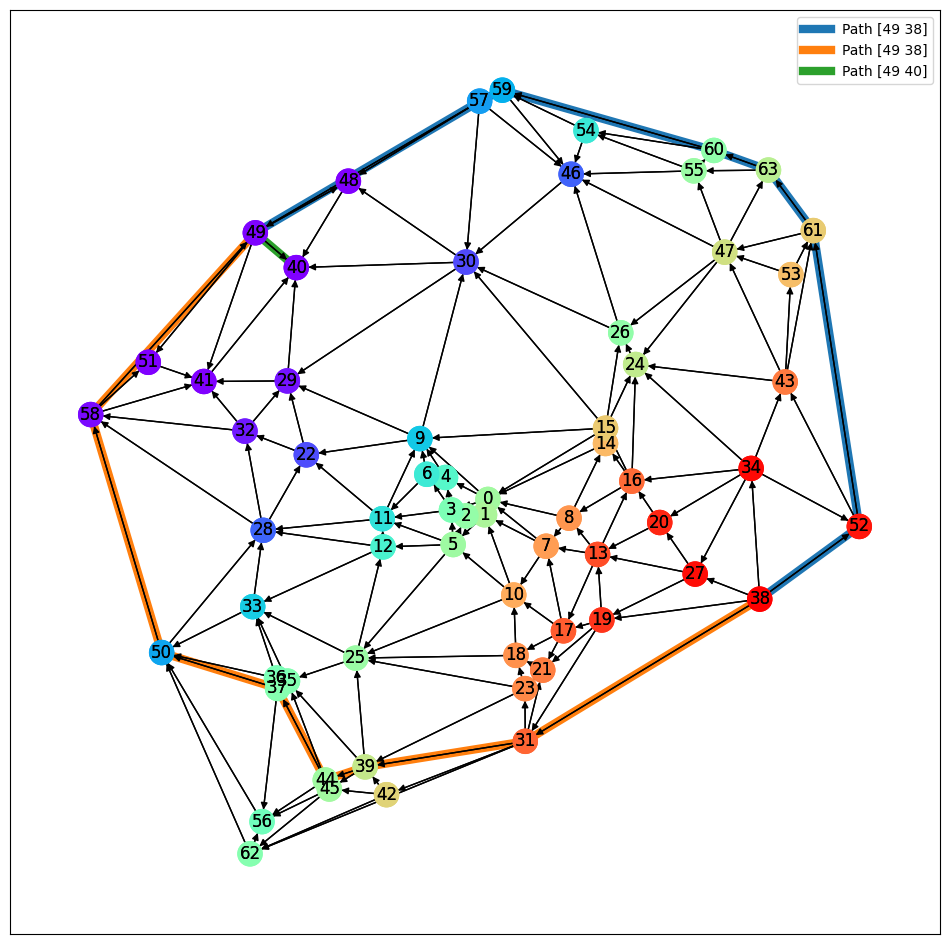

In [158]:
test_vertices_3d = np.zeros([test_vertices.shape[0], 3])
test_vertices_3d[:, :2] = test_vertices

from src.ms import MorseSmale
test_ms = MorseSmale(test_faces, test_harmonic_values, test_vertices_3d, gradient_respects_distance=False)
test_ms.define_critical_points()



print(f'test_boundary_mins: {test_boundary_mins}')
print(f'test_boundary_maxs: {test_boundary_maxs}')
print()
print(f'test_ms.mins: {test_ms.mins}')
print(f'test_ms.saddles: {test_ms.saddles}')
print(f'test_ms.maxs: {test_ms.maxs}')
print()
print(f'test_boundary_indices & test_ms.mins: {np.intersect1d(test_boundary_indices, test_ms.mins)}')
print(f'test_boundary_indices & test_ms.saddles: {np.intersect1d(test_boundary_indices, test_ms.saddles)}')
print(f'test_boundary_indices & test_ms.maxs: {np.intersect1d(test_boundary_indices, test_ms.maxs)}')
print()


plt.figure(figsize=(12, 12))

for path in test_ms.iterate_paths():
    path_x, path_y = np.transpose(test_vertices[path])
    if np.isin(path[[0, -1]], test_boundary_indices).any():
        plt.plot(path_x, path_y, linewidth=6, zorder=1, label=f'Path {path[[0, -1]]}')
    else:
        plt.plot(path_x, path_y, linewidth=6, zorder=0, color='silver')

plot_as_graph(test_vertices, test_faces, test_harmonic_values, cmap='rainbow')
plt.legend()
plt.show()

## Define Laplacian Eigen Functions

In [159]:
from scipy.sparse import linalg as spla

In [160]:
sp.sparse.linalg.eigsh

<function scipy.sparse.linalg._eigen.arpack.arpack.eigsh(A, k=6, M=None, sigma=None, which='LM', v0=None, ncv=None, maxiter=None, tol=0, return_eigenvectors=True, Minv=None, OPinv=None, mode='normal')>

In [161]:

def dirichlet_laplacian_eigenfunctions(vertices, faces, boundary_indices=None, k=10, which="LM"):
    """
    Compute k Dirichlet eigenfunctions of the Laplace–Beltrami operator:
        (-L_ff) u = lambda * M_ff u, with u(boundary)=0.

    Returns:
        evals: (k,) eigenvalues
        evecs_full: (n, k) eigenvectors padded with zeros on boundary
    """
    L = igl.cotmatrix(vertices, faces)
    M = igl.massmatrix(vertices, faces, igl.MASSMATRIX_TYPE_VORONOI)

    if boundary_indices is None:
        boundary_vertices = np.ravel(igl.is_border_vertex(faces))
    else:
        boundary_vertices = np.isin(np.arange(len(vertices), boundary_indices))
    interrior_vertices = ~boundary_vertices 



    Lff = L[interrior_vertices][:, interrior_vertices]
    Mff = M[interrior_vertices][:, interrior_vertices]

    A = (-Lff).tocsc()
    B = Mff.tocsc()

    k_eff = min(k, A.shape[0] - 2) if A.shape[0] > 2 else 1

    # Shift-invert near 0 to get smallest eigenvalues robustly
    evals, evecs_f = spla.eigsh(A, k=k_eff, M=B, sigma=0.0, which=which)

    # Pad back to full vectors with zeros on boundary
    evecs = np.zeros((vertices.shape[0], evecs_f.shape[1]), dtype=float)
    evecs[interrior_vertices, :] = evecs_f

    # Sort
    order = np.argsort(evals)
    return evals[order], evecs[:, order]


In [162]:
def second_boundary_dirichlet_laplacian_eigenfunctions(vertices, faces, boundary_indices=None, k=10, which="LM"):
    """
    """
    if boundary_indices is None:
        boundary_indices = np.argwhere(igl.is_border_vertex(faces)).ravel()

    faces_small = faces[~np.isin(faces, boundary_indices).any(axis=1)]
    vertices_small, faces_small, big2small, small2big = compact_mesh(vertices, faces_small)

    evals, evecs_small = dirichlet_laplacian_eigenfunctions(vertices_small, faces_small, k=k, which=which)
    evecs = np.zeros([vertices.shape[0], k], dtype=float)
    evecs[small2big[np.unique(faces_small)]] = evecs_small
    
    return evals, evecs

test_evals.shape = (6,)
test_evecs.shape = (64, 6)


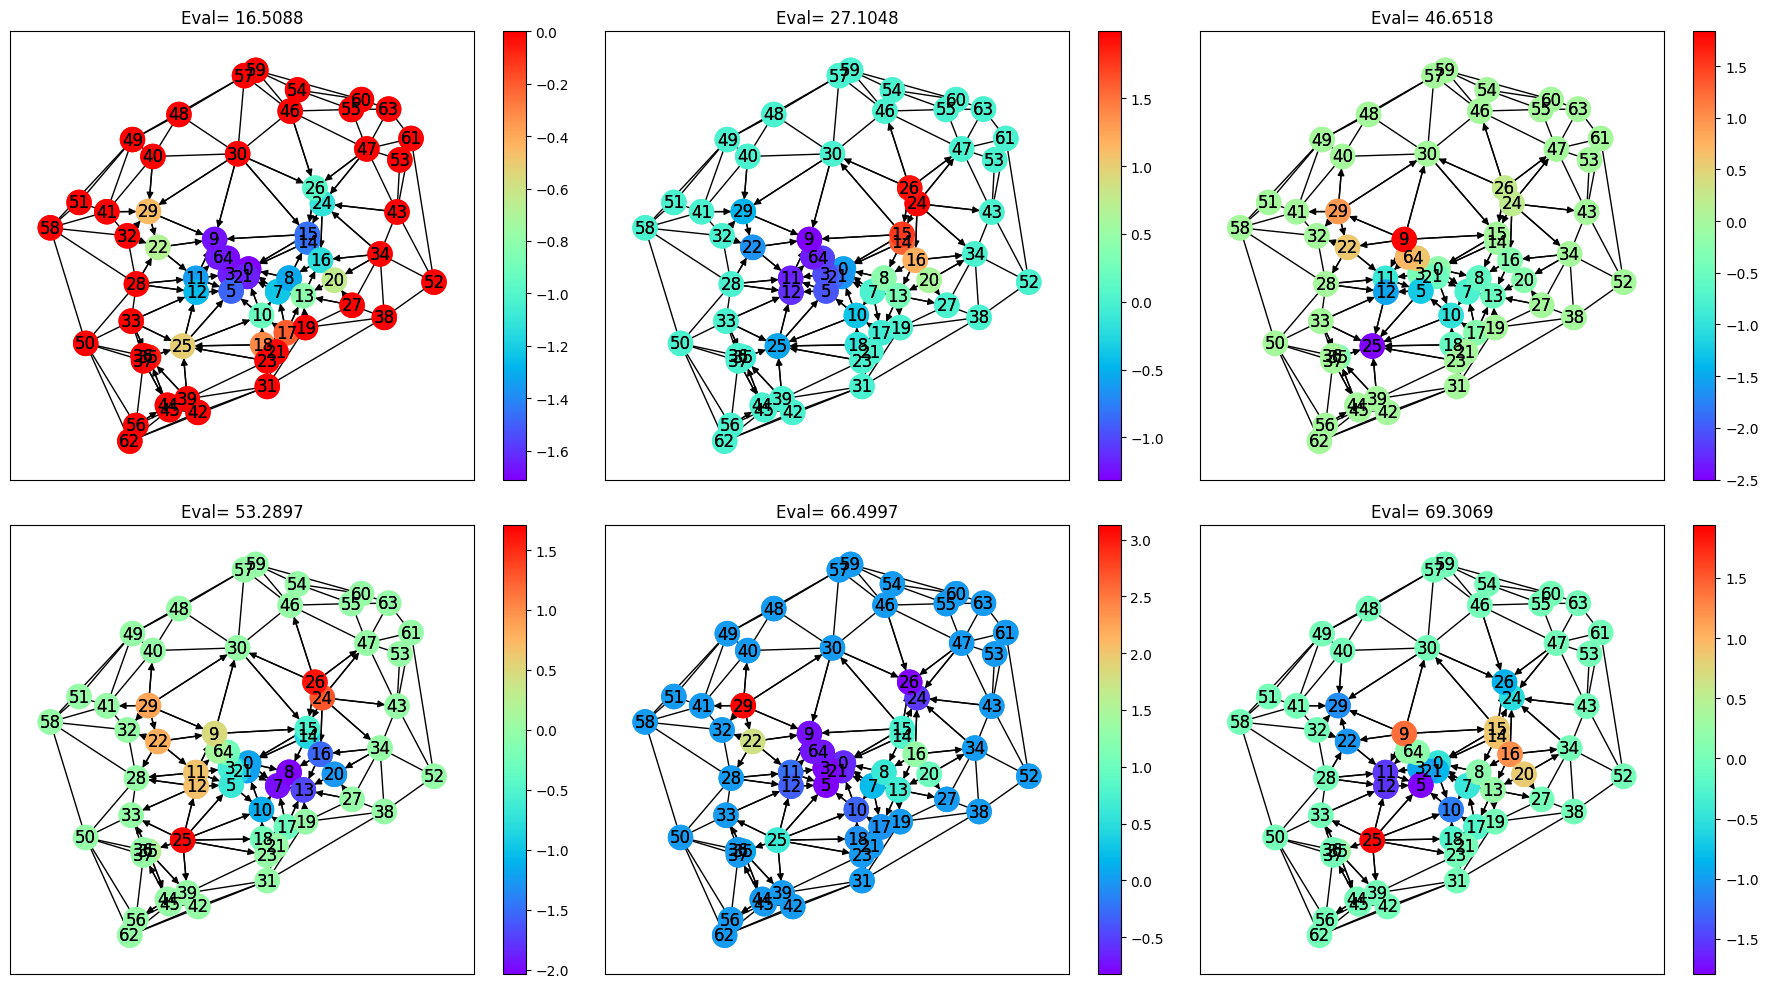

In [163]:
test_evals, test_evecs = second_boundary_dirichlet_laplacian_eigenfunctions(test_vertices, test_faces, k=6)
print(f'test_evals.shape = {test_evals.shape}')
print(f'test_evecs.shape = {test_evecs.shape}')

cmap = plt.get_cmap('rainbow')

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
for i, eval in zip(range(6), test_evals):
    i_row = i//3
    i_col = i%3
    axs[i_row, i_col].set_title(f'Eval={eval: .4f}')
    plot_as_graph(test_vertices, test_faces, test_evecs[:, i], ax=axs[i_row, i_col], cmap=cmap)


    norm = mcolors.Normalize(vmin=test_evecs[:, i].min(), vmax=test_evecs[:, i].max())

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]) 

    cbar = plt.colorbar(sm, ax=axs[i_row, i_col])

plt.tight_layout()
plt.show()


In [164]:
test_mss = [MorseSmale(test_faces, test_harmonic_values + test_evecs[:, i], test_vertices_3d, gradient_respects_distance=False) for i in range(test_evecs.shape[1])]


In [165]:
critical_colors = {'min': 'lime', 'max': 'orangered', 'saddle': 'orchid'}

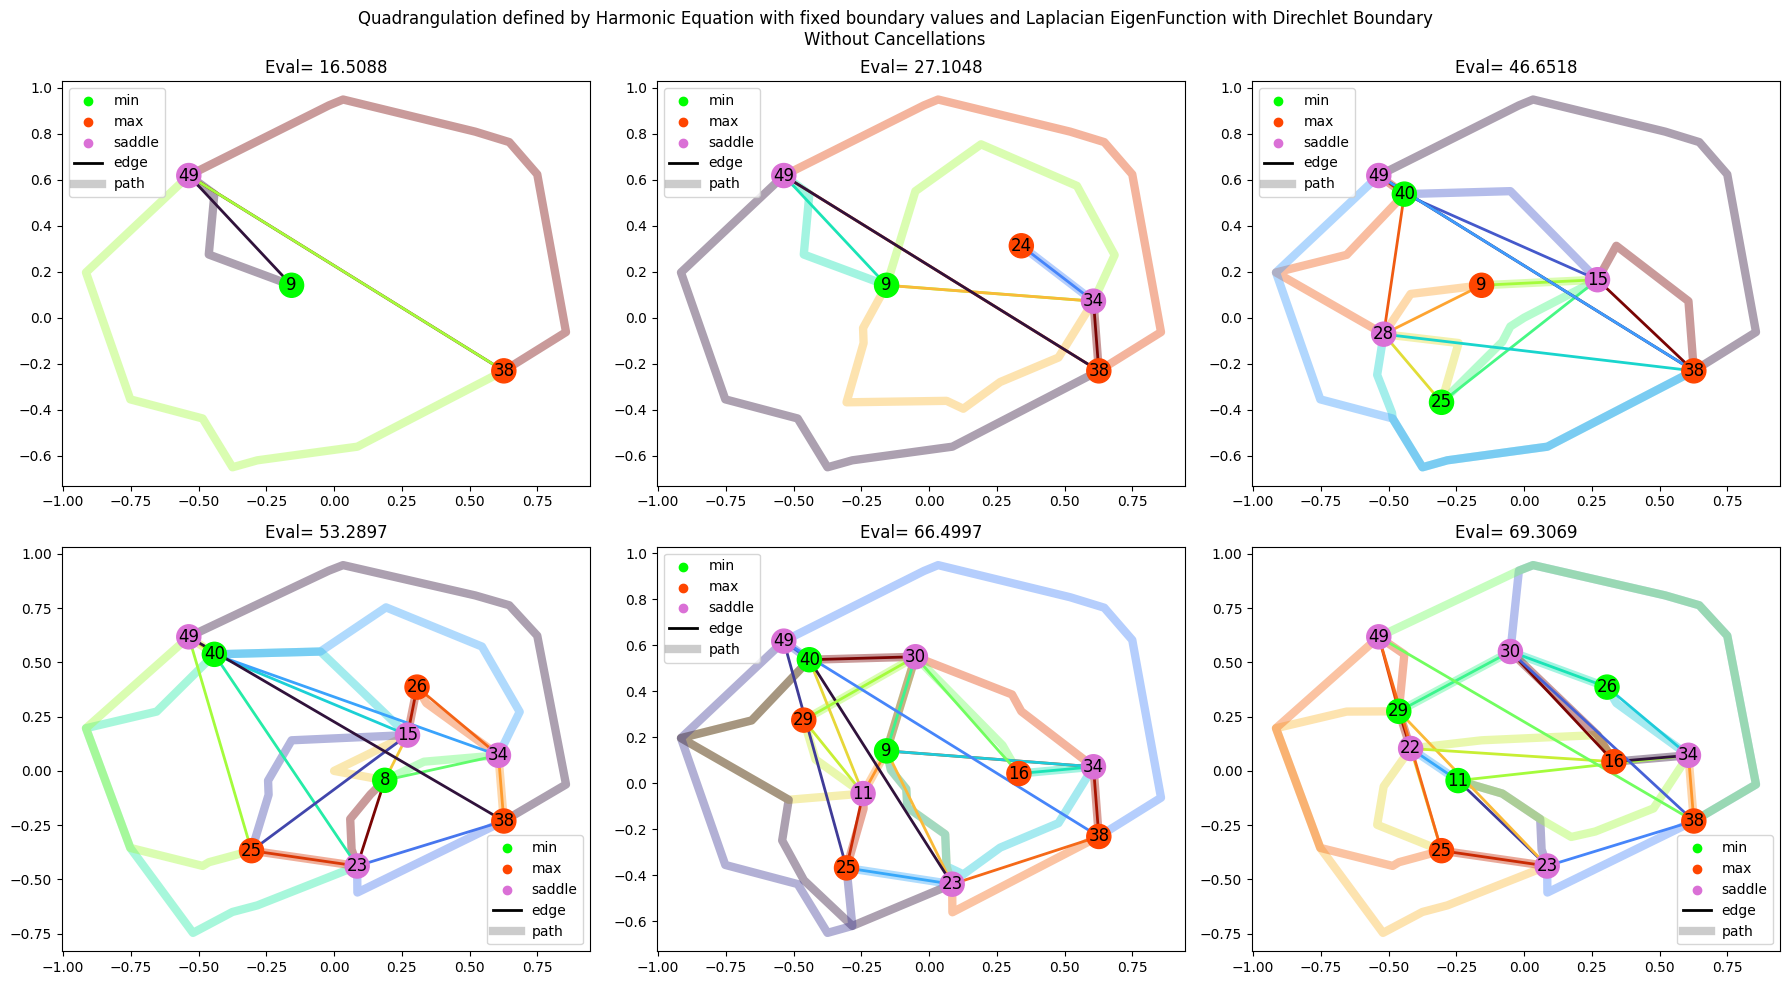

In [166]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Quadrangulation defined by Harmonic Equation with fixed boundary values and Laplacian EigenFunction with Direchlet Boundary\nWithout Cancellations')

for i, (eval, msi) in zip(range(6), zip(test_evals, test_mss)):
    i_row = i//3
    i_col = i%3
    axs[i_row, i_col].set_title(f'Eval={eval: .4f}')

    msi.define_critical_points()
    g = msi.get_paths_graph()
    g_nodes = np.array(list(g.nodes))
    g_node_types = np.array(['regular' for node in g.nodes])
    g_node_types[np.isin(g_nodes, msi.mins)] = 'min'
    g_node_types[np.isin(g_nodes, msi.maxs)] = 'max'
    g_node_types[np.isin(g_nodes, msi.saddles)] = 'saddle'
    g_node_colors = np.vectorize(critical_colors.get)(g_node_types)
    for name, color in critical_colors.items():
        axs[i_row, i_col].scatter([], [], color=color, label=name)
    
    edge_colors = [mcolors.to_hex(c) for c in plt.get_cmap('turbo')(np.linspace(0, 1, nx.number_of_edges(g)))]
    edge_colors = np.random.choice(edge_colors, len(edge_colors), replace=False)
    nx.draw_networkx(g, pos=test_vertices, node_color=g_node_colors, edge_color=edge_colors, width=2, hide_ticks=False, ax=axs[i_row, i_col])
    for (e0, e1, data), color in zip(g.edges(data=True), edge_colors):
        path = data['path']
        path_x, path_y = np.transpose(test_vertices[path])
        axs[i_row, i_col].plot(path_x, path_y, linewidth=6, alpha=0.4, zorder=0, color=color)
        
    axs[i_row, i_col].plot([], [], color='black', alpha=1.0, linewidth=2, label='edge')
    axs[i_row, i_col].plot([], [], color='black', alpha=0.2, linewidth=6, label='path')
    


    axs[i_row, i_col].legend()

plt.tight_layout()
plt.show()

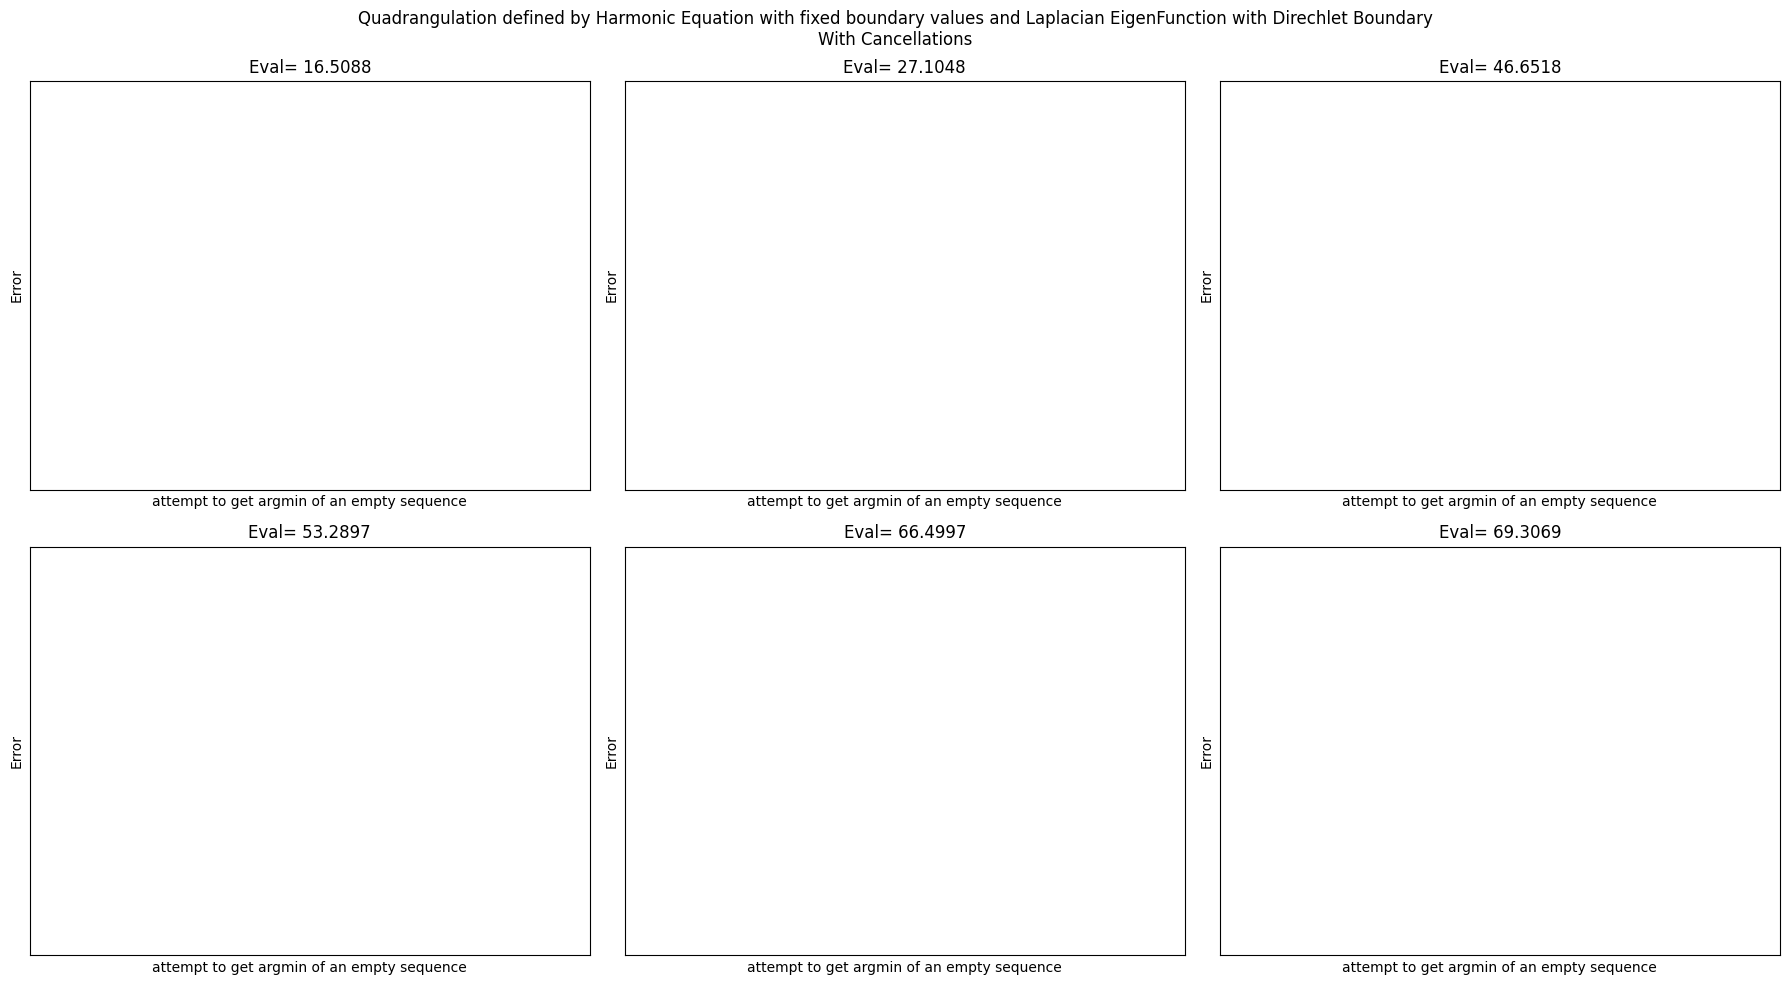

In [167]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Quadrangulation defined by Harmonic Equation with fixed boundary values and Laplacian EigenFunction with Direchlet Boundary\nWith Cancellations')

for i, (eval, msi) in zip(range(6), zip(test_evals, test_mss)):
    i_row = i//3
    i_col = i%3
    axs[i_row, i_col].set_title(f'Eval={eval: .4f}')

    msi.define_critical_points()
    try:
        g = msi.get_paths_graph_after_cancellations(protected_saddles=test_boundary_indices)
    except Exception as err:
        axs[i_row, i_col].set_xlabel(str(err))
        axs[i_row, i_col].set_ylabel('Error')
        axs[i_row, i_col].set_xticks([])
        axs[i_row, i_col].set_yticks([])
        continue

    g_nodes = np.array(list(g.nodes))
    g_node_types = np.array(['regular' for node in g.nodes])
    g_node_types[np.isin(g_nodes, msi.mins)] = 'min'
    g_node_types[np.isin(g_nodes, msi.maxs)] = 'max'
    g_node_types[np.isin(g_nodes, msi.saddles)] = 'saddle'
    g_node_colors = np.vectorize(critical_colors.get)(g_node_types)
    for name, color in critical_colors.items():
        axs[i_row, i_col].scatter([], [], color=color, label=name)
    
    edge_colors = [mcolors.to_hex(c) for c in plt.get_cmap('turbo')(np.linspace(0, 1, nx.number_of_edges(g)))]
    edge_colors = np.random.choice(edge_colors, len(edge_colors), replace=False)
    nx.draw_networkx(g, pos=test_vertices, node_color=g_node_colors, edge_color=edge_colors, hide_ticks=False, width=2, ax=axs[i_row, i_col])
    for (e0, e1, data), color in zip(g.edges(data=True), edge_colors):
        path = data['path']
        path_x, path_y = np.transpose(test_vertices[path])
        axs[i_row, i_col].plot(path_x, path_y, linewidth=6, alpha=0.4, zorder=0, color=color)
        
    axs[i_row, i_col].plot([], [], color='black', alpha=1.0, linewidth=2, label='edge')
    axs[i_row, i_col].plot([], [], color='black', alpha=0.2, linewidth=6, label='path')
    


    axs[i_row, i_col].legend()

plt.tight_layout()
plt.show()

# Quadrangulation of Manifold Components

In [168]:
(boundary_indices, 
 boundary_values, 
 boundary_mins, 
 boundary_maxs, 
 boundary_cons) = detect_boundary_parameters(vertices, faces, default_value=1)

print(f'boundary_mins: {boundary_mins}')
print(f'boundary_maxs: {boundary_maxs}')
print(f'boundary_cons: {boundary_cons}')

boundary_mins: [ 268  269 4420  446  447  454  453 4423 4453 4439 1030 4670 5009 1603
 1604  886]
boundary_maxs: [ 274  314  315  344  575  576  598  618 1135 1136 1426 1748  886]
boundary_cons: [886]


In [170]:


norm_val = mcolors.TwoSlopeNorm(vmin=boundary_values.min(), vcenter=0, vmax=abs(boundary_values).max())
node_colors_val = [c for c in plt.get_cmap('coolwarm')(norm_val(boundary_values))]


In [171]:
import numpy as np
from collections import defaultdict, deque

def get_manifold_components(faces):
    """
    Returns the labels of manifold components for each face.

    Each component is manifold, separated by non-manifold edges.
    """

    n_faces = faces.shape[0]
    component_labels = -np.ones(n_faces, dtype=int)

    # --- Step 1: Build edge → faces map ---
    edge_to_faces = defaultdict(list)

    for fi, face in enumerate(faces):
        k = len(face)
        for i in range(k):
            v1 = face[i]
            v2 = face[(i + 1) % k]

            edge = tuple(sorted((v1, v2)))
            edge_to_faces[edge].append(fi)

    # --- Step 2: Build adjacency using manifold edges only ---
    adjacency = defaultdict(list)

    for edge, incident_faces in edge_to_faces.items():
        if len(incident_faces) == 2:  # manifold edge
            f1, f2 = incident_faces
            adjacency[f1].append(f2)
            adjacency[f2].append(f1)

    # --- Step 3: Connected components on faces ---
    current_label = 0

    for start_face in range(n_faces):
        if component_labels[start_face] != -1:
            continue

        # BFS / DFS
        queue = deque([start_face])
        component_labels[start_face] = current_label

        while queue:
            f = queue.popleft()

            for neighbor in adjacency[f]:
                if component_labels[neighbor] == -1:
                    component_labels[neighbor] = current_label
                    queue.append(neighbor)

        current_label += 1

    return component_labels

In [172]:
component_labels = get_manifold_components(faces)

In [173]:
pl = pv.Plotter(shape=(1, 2), window_size=(1200, 600))

pl.subplot(0, 0)
pl.add_text('Boundary Values')
mesh0 = vis.get_pv_mesh(vertices, faces)
pl.add_mesh(mesh0, color='white', smooth_shading=False, show_edges=True, opacity=1.0)


vis.add_graph_to_plotter(pl, boundary_graph, boundary_graph_pos, node_color=node_colors_val, 
                         edge_color='black', edge_width=2, node_size=10, add_labels=False)



pl.subplot(0, 1)
pl.add_text('Manifold Components and Critical Points an the Boundary')
mesh1 = vis.get_pv_mesh(vertices, faces)
mesh1.cell_data['component'] = component_labels
pl.add_mesh(mesh1, scalars='component', cmap='Set2', smooth_shading=False, show_edges=True, opacity=1.0, categories=True)

pl.add_points(vertices[boundary_mins], color='deepskyblue', point_size=12, render_points_as_spheres=True)
pl.add_points(vertices[boundary_maxs], color='orangered', point_size=12, render_points_as_spheres=True)
pl.add_points(vertices[boundary_cons], color='lime', point_size=14, render_points_as_spheres=True)

pl.link_views()
pl.show()

Widget(value='<iframe src="http://localhost:34101/index.html?ui=P_0x7e2cb02d5160_13&reconnect=auto" class="pyv…

In [174]:
nmb = NonmanifoldBoundaryDetecter(faces, vertices)
boundary_graph = nmb.get_boundary_graph()


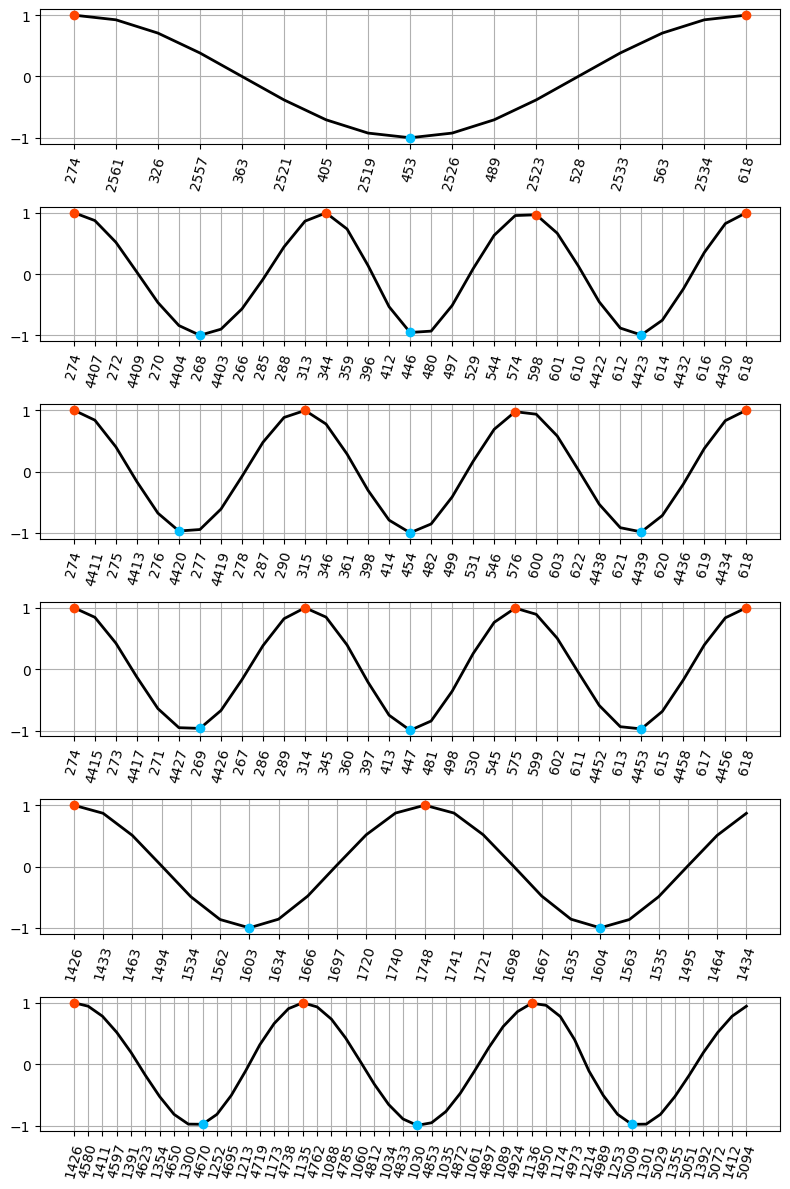

In [175]:
chains = get_chains(boundary_graph)

fig, axs = plt.subplots(len(chains), figsize=(8, 12))
for i, chain in enumerate(chains):
    chain_values = boundary_values[(boundary_indices.reshape(-1, 1) == chain).argmax(axis=0)]

    chain_mins_x = np.argwhere(np.isin(chain, boundary_mins)).ravel()
    chain_maxs_x = np.argwhere(np.isin(chain, boundary_maxs)).ravel()
    
    axs[i].plot(chain_values, color='black', linewidth=2)
    axs[i].scatter(chain_mins_x, chain_values[chain_mins_x], color='deepskyblue', zorder=2)
    axs[i].scatter(chain_maxs_x, chain_values[chain_maxs_x], color='orangered', zorder=2)
    axs[i].set_xticks(range(len(chain)), chain,)
    axs[i].tick_params(axis='x', rotation=75) 
    axs[i].grid(True)
plt.tight_layout()
    

In [176]:
from tqdm import tqdm

In [177]:
components_mss = []
components_boundary_indices3 = []
components_boundary_values3 = []


for i in np.unique(component_labels):
#for i in [0]:
    print('Component:', i)
    V2, F2, old2new, new2old = triangletools.compact_mesh(vertices, faces[component_labels == i])
    #print('V2.shape, F2.shape =', V2.shape, F2.shape)

    boundary_is_in_component = np.isin(boundary_indices, np.unique(faces[component_labels == i]))
    comp_boundary_indices_old = boundary_indices[boundary_is_in_component]
    comp_boundary_indices_new = old2new[comp_boundary_indices_old]
    comp_boundary_values = boundary_values[boundary_is_in_component]
    
    comp_boundary_edges = np.unique(np.sort(np.vstack(F2[:, [[0, 1], [0, 2], [1, 2]]]), axis=1), axis=0)
    comp_boundary_edges = comp_boundary_edges[np.isin(comp_boundary_edges, comp_boundary_indices_new).all(axis=1)]

    F3, V3i = gpy.cut_edges(F2, comp_boundary_edges)
    V3 = V2[V3i]

    comp_boundary_indices_new3, comp_boundary_values3 = np.argwhere(comp_boundary_indices_new == V3i[:, None]).transpose()
    comp_boundary_values3 = comp_boundary_values[comp_boundary_values3]
    #comp_boundary_mins3 = detect_mins(F3, comp_boundary_indices_new3, comp_boundary_values3)
    #comp_boundary_maxs3 = detect_maxs(F3, comp_boundary_indices_new3, comp_boundary_values3)
    components_boundary_indices3.append(comp_boundary_indices_new3)
    components_boundary_values3.append(comp_boundary_values3)


    F3 = flip_ears(F3)
    #V3, F3 = split_edges_arroud_saddles(V3, F3, comp_boundary_mins3)
    #V3, F3 = split_edges_arroud_saddles(V3, F3, comp_boundary_maxs3)
    print('V3.shape, F3.shape =', V3.shape, F3.shape)

    u = solve_second_boundary_hermonics(V3, F3, comp_boundary_indices_new3, comp_boundary_values3, 
                                        alpha=0.5, derivative=-0.2, return_values=False)

    evals, evecs = second_boundary_dirichlet_laplacian_eigenfunctions(V3, F3, k=4)
    evec = evecs[:, 0]

    components_mss.append(MorseSmale(faces=F3, values=u + evec, vertices=V3))
    components_mss[-1].define_critical_points()
    
    




Component: 0
V3.shape, F3.shape = (5747, 3) (11304, 3)
Component: 1
V3.shape, F3.shape = (224, 3) (398, 3)
Component: 2
V3.shape, F3.shape = (216, 3) (382, 3)
Component: 3
V3.shape, F3.shape = (194, 3) (338, 3)
Component: 4
V3.shape, F3.shape = (2361, 3) (4572, 3)
Component: 5
V3.shape, F3.shape = (3068, 3) (5990, 3)


In [178]:
pl = pv.Plotter(window_size=(800, 800))
for msi in tqdm(components_mss, total=len(components_mss)):
    #msi.define_critical_points()
    vis.add_complex_to_plotter(pl, msi)

pl.show()

100%|██████████| 6/6 [00:13<00:00,  2.28s/it]


Widget(value='<iframe src="http://localhost:34101/index.html?ui=P_0x7e2d9c366180_14&reconnect=auto" class="pyv…

In [180]:
rows = int(len(components_mss)**0.5)
cols = np.ceil(len(components_mss)/rows).astype(int)

pl = pv.Plotter(shape=(rows, cols), window_size=(1400, 1000))

for i in tqdm(range(len(components_mss)), total=len(components_mss)):
    i_col = i//rows
    i_row = i% rows
    pl.subplot(i_row, i_col)
    for j, ms in enumerate(components_mss):
        if i == j:
            vis.add_complex_to_plotter(pl, ms, eps=0)
        else:
            vis.add_complex_to_plotter(pl, ms, opacity=0.4, with_values=False, with_critical_points=False, with_paths=False)

pl.link_views()
pl.show()


100%|██████████| 6/6 [00:14<00:00,  2.35s/it]


Widget(value='<iframe src="http://localhost:34101/index.html?ui=P_0x7e2ccb6ad070_16&reconnect=auto" class="pyv…